# 🏗️ Архитектура базы данных Qyzmeta-Bot

## 📊 Графическое представление всех моделей данных

Этот блокнот содержит визуализацию архитектуры базы данных проекта **Qyzmeta-Bot** - платформы цифровизации ЖКХ для Казахстана.

### 🎯 Содержание:
1. **Импорт библиотек** - подключение необходимых инструментов
2. **Диаграмма ER** - схема базы данных и связей между таблицами
3. **Модели данных** - подробное описание каждой модели
4. **Перечисления (Enums)** - статусы, роли и категории
5. **Связи между таблицами** - foreign keys и relationships
6. **Статистика моделей** - количество полей, типы данных

---

In [1]:
# Импорт необходимых библиотек для визуализации
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from datetime import datetime

# Настройка matplotlib для лучшего отображения
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'Arial'

print("✅ Библиотеки успешно импортированы!")
print("📊 Готов к созданию диаграмм моделей базы данных Qyzmeta-Bot")

✅ Библиотеки успешно импортированы!
📊 Готов к созданию диаграмм моделей базы данных Qyzmeta-Bot


In [5]:
# 📋 Определение структуры всех моделей базы данных

models_structure = {
    'User': {
        'position': (2, 8),
        'fields': [
            'id: INTEGER (PK)',
            'user_id: BIGINTEGER (UK)',
            'first_name: STRING(50)',
            'last_name: STRING(50)',
            'username: STRING(50)',
            'user_language: UserLanguage',
            'is_bot: BOOLEAN',
            'is_premium: BOOLEAN',
            'is_business: BOOLEAN',
            'role: UserRole',
            'phone: STRING(50)',
            'email: STRING(50)',
            'city: STRING(100)',
            'is_banned: BOOLEAN',
            'is_blocked: BOOLEAN',
            'is_blocked_by_admin: BOOLEAN',
            'is_subscribed_to_channel: BOOLEAN',
            'is_subscribed_to_group: BOOLEAN',
            'subscription_expires_at: DATETIME',
            'last_active: DATETIME',
            'wants_notifications: BOOLEAN',
            'invited_by_id: INTEGER (FK→users.id)'
        ],
        'color': '#E3F2FD'  # Голубой
    },
    
    'JK': {
        'position': (8, 8),
        'fields': [
            'id: INTEGER (PK)',
            'uuid: STRING(36) (UK)',
            'name: STRING(100)',
            'city: STRING(50)',
            'street: STRING(100)',
            'house: STRING(20)',
            'block: STRING(20)',
            'channel_id: BIGINTEGER',
            'group_id: BIGINTEGER',
            'id_uk: BIGINTEGER',
            'image_id: STRING(100)',
            'bus_image_id: STRING(100)',
            'creator_id: BIGINTEGER'
        ],
        'color': '#E8F5E8'  # Зеленый
    },
    
    'UserJK': {
        'position': (5, 6),
        'fields': [
            'id: INTEGER (PK)',
            'user_id: BIGINTEGER',
            'jk_id: INTEGER (FK→jks.id)',
            'appartment: STRING(20)',
            'is_resident: BOOLEAN',
            'is_admin: BOOLEAN',
            'is_uk: BOOLEAN',
            'is_service: BOOLEAN'
        ],
        'color': '#FFF3E0'  # Оранжевый
    },
    
    'Offer': {
        'position': (5, 3),
        'fields': [
            'id: INTEGER (PK)',
            'uuid: STRING(36)',
            'category: STRING(50)',
            'title: STRING(200)',
            'description: TEXT',
            'media_id: STRING(200)',
            'user_id: BIGINTEGER',
            'user_jk_id: INTEGER (FK→user_jk.id)',
            'status: OfferStatus'
        ],
        'color': '#FCE4EC'  # Розовый
    },
    
    'Lot': {
        'position': (2, 3),
        'fields': [
            'id: INTEGER (PK)',
            'offer_type: LotOfferType',
            'type_lot: STRING(50)',
            'name: STRING(100)',
            'description: TEXT',
            'price: FLOAT',
            'city: STRING(100)',
            'phone: STRING(50)',
            'image_id: STRING(150)',
            'owner_id: BIGINTEGER (FK→users.user_id)',
            'status: LotStatus',
            'visibility: LotVisibility',
            'expires_at: DATETIME'
        ],
        'color': '#F3E5F5'  # Фиолетовый
    },
    
    'LotLimit': {
        'position': (8, 3),
        'fields': [
            'id: INTEGER (PK)',
            'role: UserRole (UK)',
            'limit: INTEGER'
        ],
        'color': '#FFEBEE'  # Красный
    }
}

# 🔗 Определение связей между таблицами
relationships = [
    {'from': 'User', 'to': 'UserJK', 'label': '1:N (user_id)', 'color': '#666'},
    {'from': 'JK', 'to': 'UserJK', 'label': '1:N (jk_id)', 'color': '#666'},
    {'from': 'UserJK', 'to': 'Offer', 'label': '1:N (user_jk_id)', 'color': '#666'},
    {'from': 'User', 'to': 'Lot', 'label': '1:N (owner_id)', 'color': '#666'},
    {'from': 'User', 'to': 'User', 'label': 'Self-ref (invited_by_id)', 'color': '#999'}
]

print("✅ Структура моделей определена!")
print(f"📊 Всего моделей: {len(models_structure)}")
print(f"🔗 Всего связей: {len(relationships)}")

✅ Структура моделей определена!
📊 Всего моделей: 6
🔗 Всего связей: 5


C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\4159809942.py:108: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\4159809942.py:108: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\4159809942.py:108: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\4159809942.py:108: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\4159809942.py:108: UserWarning: Glyph 127380 (\N{SQUARED ID}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\4159809942.py:108: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial.
  plt.tight_la

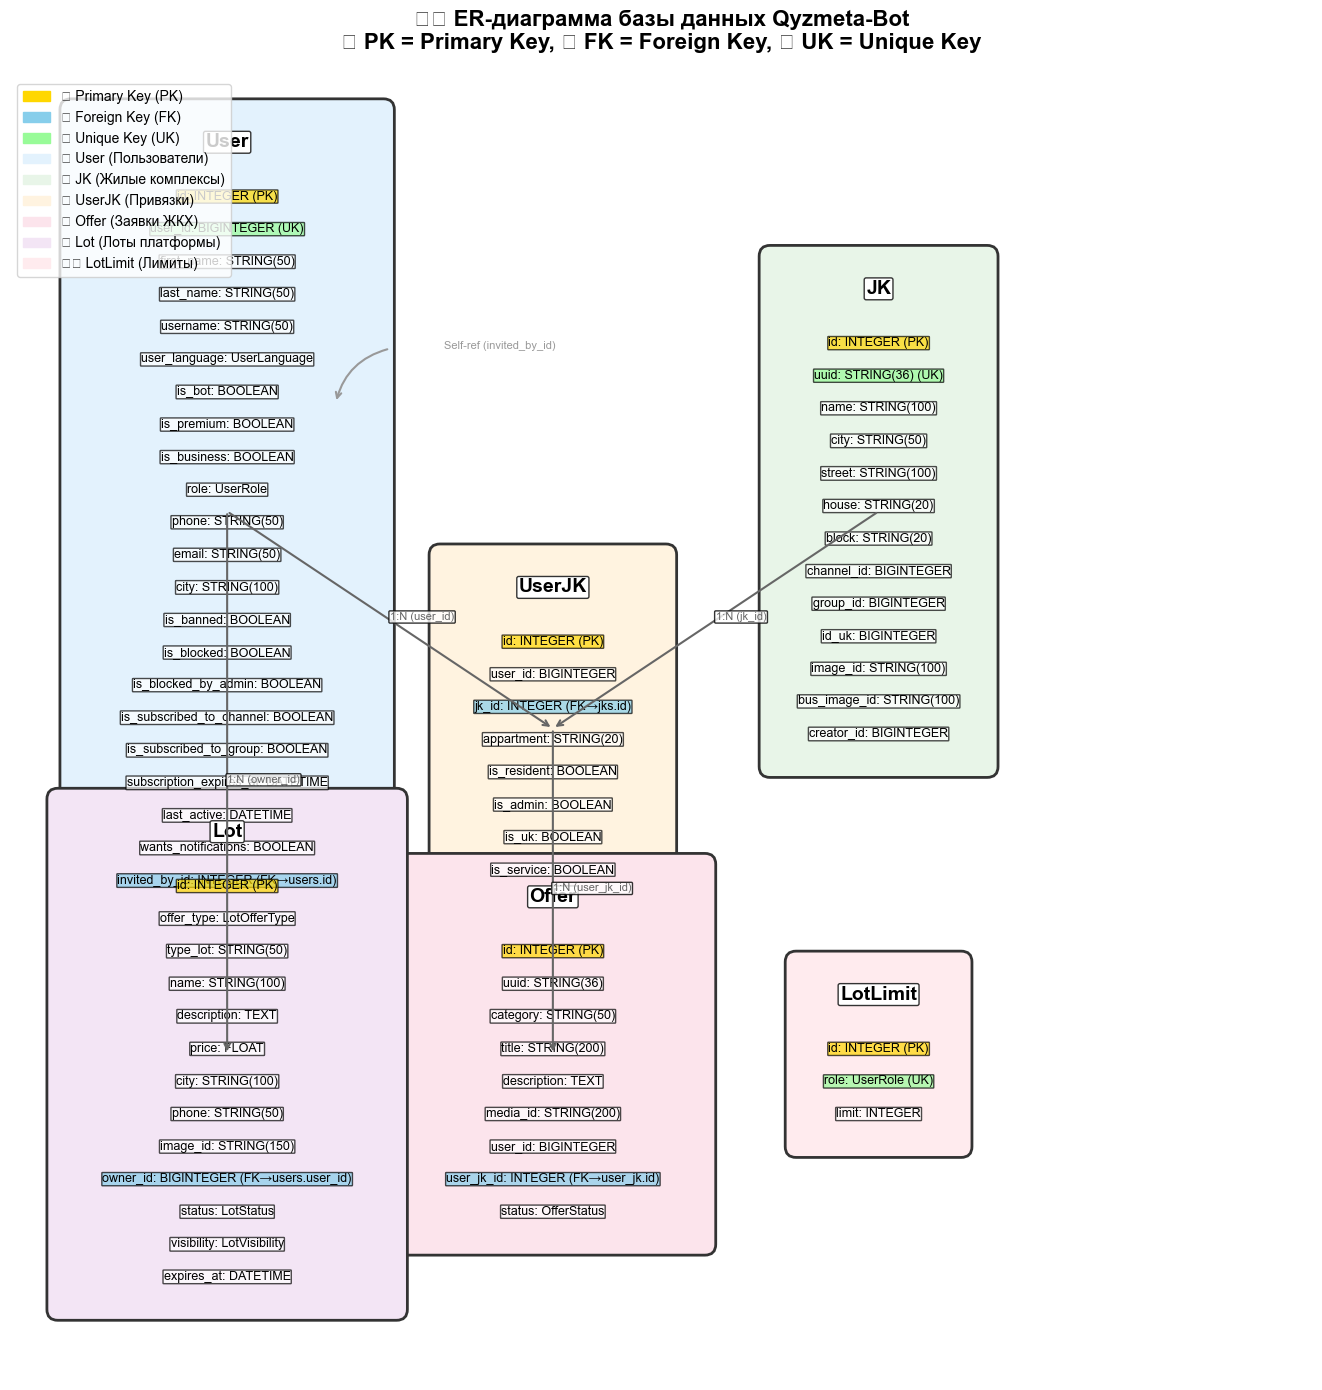

In [6]:
# 🎨 Создание ER-диаграммы базы данных

def create_er_diagram():
    fig, ax = plt.subplots(1, 1, figsize=(18, 14))
    
    # Функция для рисования модели
    def draw_model(model_name, model_data, ax):
        x, y = model_data['position']
        fields = model_data['fields']
        color = model_data['color']
        
        # Вычисляем размер прямоугольника
        max_width = max(len(field) for field in fields) * 0.08
        height = len(fields) * 0.3 + 0.8
        
        # Рисуем основной прямоугольник
        rect = FancyBboxPatch(
            (x - max_width/2, y - height/2),
            max_width, height,
            boxstyle="round,pad=0.1",
            facecolor=color,
            edgecolor='#333',
            linewidth=2
        )
        ax.add_patch(rect)
        
        # Добавляем заголовок модели
        ax.text(x, y + height/2 - 0.3, model_name, 
                ha='center', va='center', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.1", facecolor='white', edgecolor='#333'))
        
        # Добавляем поля
        for i, field in enumerate(fields):
            field_y = y + height/2 - 0.8 - (i * 0.3)
            
            # Выделяем PK, FK, UK
            if '(PK)' in field:
                field_color = '#FFD700'  # Золотой для PK
            elif '(FK' in field:
                field_color = '#87CEEB'  # Голубой для FK
            elif '(UK)' in field:
                field_color = '#98FB98'  # Светло-зеленый для UK
            else:
                field_color = 'white'
            
            ax.text(x, field_y, field, ha='center', va='center', fontsize=9,
                   bbox=dict(boxstyle="round,pad=0.05", facecolor=field_color, alpha=0.7))
    
    # Рисуем все модели
    for model_name, model_data in models_structure.items():
        draw_model(model_name, model_data, ax)
    
    # Рисуем связи
    def draw_relationship(from_model, to_model, label, color, ax):
        from_pos = models_structure[from_model]['position']
        to_pos = models_structure[to_model]['position']
        
        # Специальная обработка self-reference
        if from_model == to_model:
            # Рисуем петлю
            ax.annotate('', xy=(from_pos[0] + 1, from_pos[1] + 1), 
                       xytext=(from_pos[0] + 1.5, from_pos[1] + 1.5),
                       arrowprops=dict(arrowstyle='->', color=color, lw=1.5,
                                     connectionstyle="arc3,rad=0.3"))
            ax.text(from_pos[0] + 2, from_pos[1] + 1.5, label, 
                   fontsize=8, color=color)
        else:
            # Обычная связь
            ax.annotate('', xy=to_pos, xytext=from_pos,
                       arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
            
            # Подпись связи
            mid_x = (from_pos[0] + to_pos[0]) / 2
            mid_y = (from_pos[1] + to_pos[1]) / 2
            ax.text(mid_x, mid_y, label, fontsize=8, color=color,
                   bbox=dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.8))
    
    # Рисуем все связи
    for rel in relationships:
        draw_relationship(rel['from'], rel['to'], rel['label'], rel['color'], ax)
    
    # Настройки графика
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Заголовок
    plt.title('🏗️ ER-диаграмма базы данных Qyzmeta-Bot\n' + 
              '🔑 PK = Primary Key, 🔗 FK = Foreign Key, 🆔 UK = Unique Key', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Легенда
    legend_elements = [
        patches.Patch(color='#FFD700', label='🔑 Primary Key (PK)'),
        patches.Patch(color='#87CEEB', label='🔗 Foreign Key (FK)'),
        patches.Patch(color='#98FB98', label='🆔 Unique Key (UK)'),
        patches.Patch(color='#E3F2FD', label='👤 User (Пользователи)'),
        patches.Patch(color='#E8F5E8', label='🏠 JK (Жилые комплексы)'),
        patches.Patch(color='#FFF3E0', label='🔗 UserJK (Привязки)'),
        patches.Patch(color='#FCE4EC', label='📋 Offer (Заявки ЖКХ)'),
        patches.Patch(color='#F3E5F5', label='📦 Lot (Лоты платформы)'),
        patches.Patch(color='#FFEBEE', label='⚖️ LotLimit (Лимиты)')
    ]
    
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1))
    
    plt.tight_layout()
    plt.show()

# Создаем диаграмму
create_er_diagram()

## 📊 Детальное описание моделей

### 🎯 Основные сущности системы

#### 👤 **User** - Пользователи системы
Центральная модель для всех пользователей экосистемы LotBox Platform:
- **Идентификация**: user_id (Telegram ID), username, имя
- **Роли**: от GUEST до CREATOR с разными правами доступа
- **Локализация**: поддержка казахского и русского языков
- **Telegram атрибуты**: is_bot, is_premium, is_business
- **Контакты**: phone, email, city
- **Управление**: блокировки, подписки, уведомления
- **Реферальная система**: invited_by_id для отслеживания приглашений

#### 🏠 **JK** - Жилые комплексы
Модель для управления жилыми комплексами:
- **UUID**: уникальный идентификатор для API интеграций
- **Адрес**: city, street, house, block
- **Интеграции**: channel_id, group_id для Telegram каналов/групп
- **Управление**: id_uk для привязки управляющих компаний
- **Медиа**: image_id и bus_image_id для системы обмена файлами

#### 🔗 **UserJK** - Привязка пользователей к ЖК
Связующая таблица с ролевой моделью:
- **Квартира**: appartment для указания номера
- **Роли в ЖК**: is_resident, is_admin, is_uk, is_service
- **Уникальность**: один пользователь может быть привязан к ЖК только один раз

#### 📋 **Offer** - Заявки жителей
Заявки по ЖКХ от жителей:
- **UUID**: для API и внешних интеграций
- **Категории**: домофон, электрика, сантехника, благоустройство
- **Мультимедиа**: media_id для прикрепления фото/видео
- **Статусы**: от ACTIVE до ARCHIVED
- **Привязка**: через user_jk_id к конкретной квартире

#### 📦 **Lot** - Лоты платформы
Универсальная модель для LotBox Platform:
- **Типы**: задачи, товары, услуги, обмен, аренда
- **Коммерция**: price, city для торговых операций
- **Владелец**: owner_id привязка к пользователю
- **Жизненный цикл**: status, visibility, expires_at

#### ⚖️ **LotLimit** - Лимиты по ролям
Система ограничений:
- **Роль**: связь с UserRole
- **Лимит**: количество лотов для каждой роли

C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\189766926.py:93: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


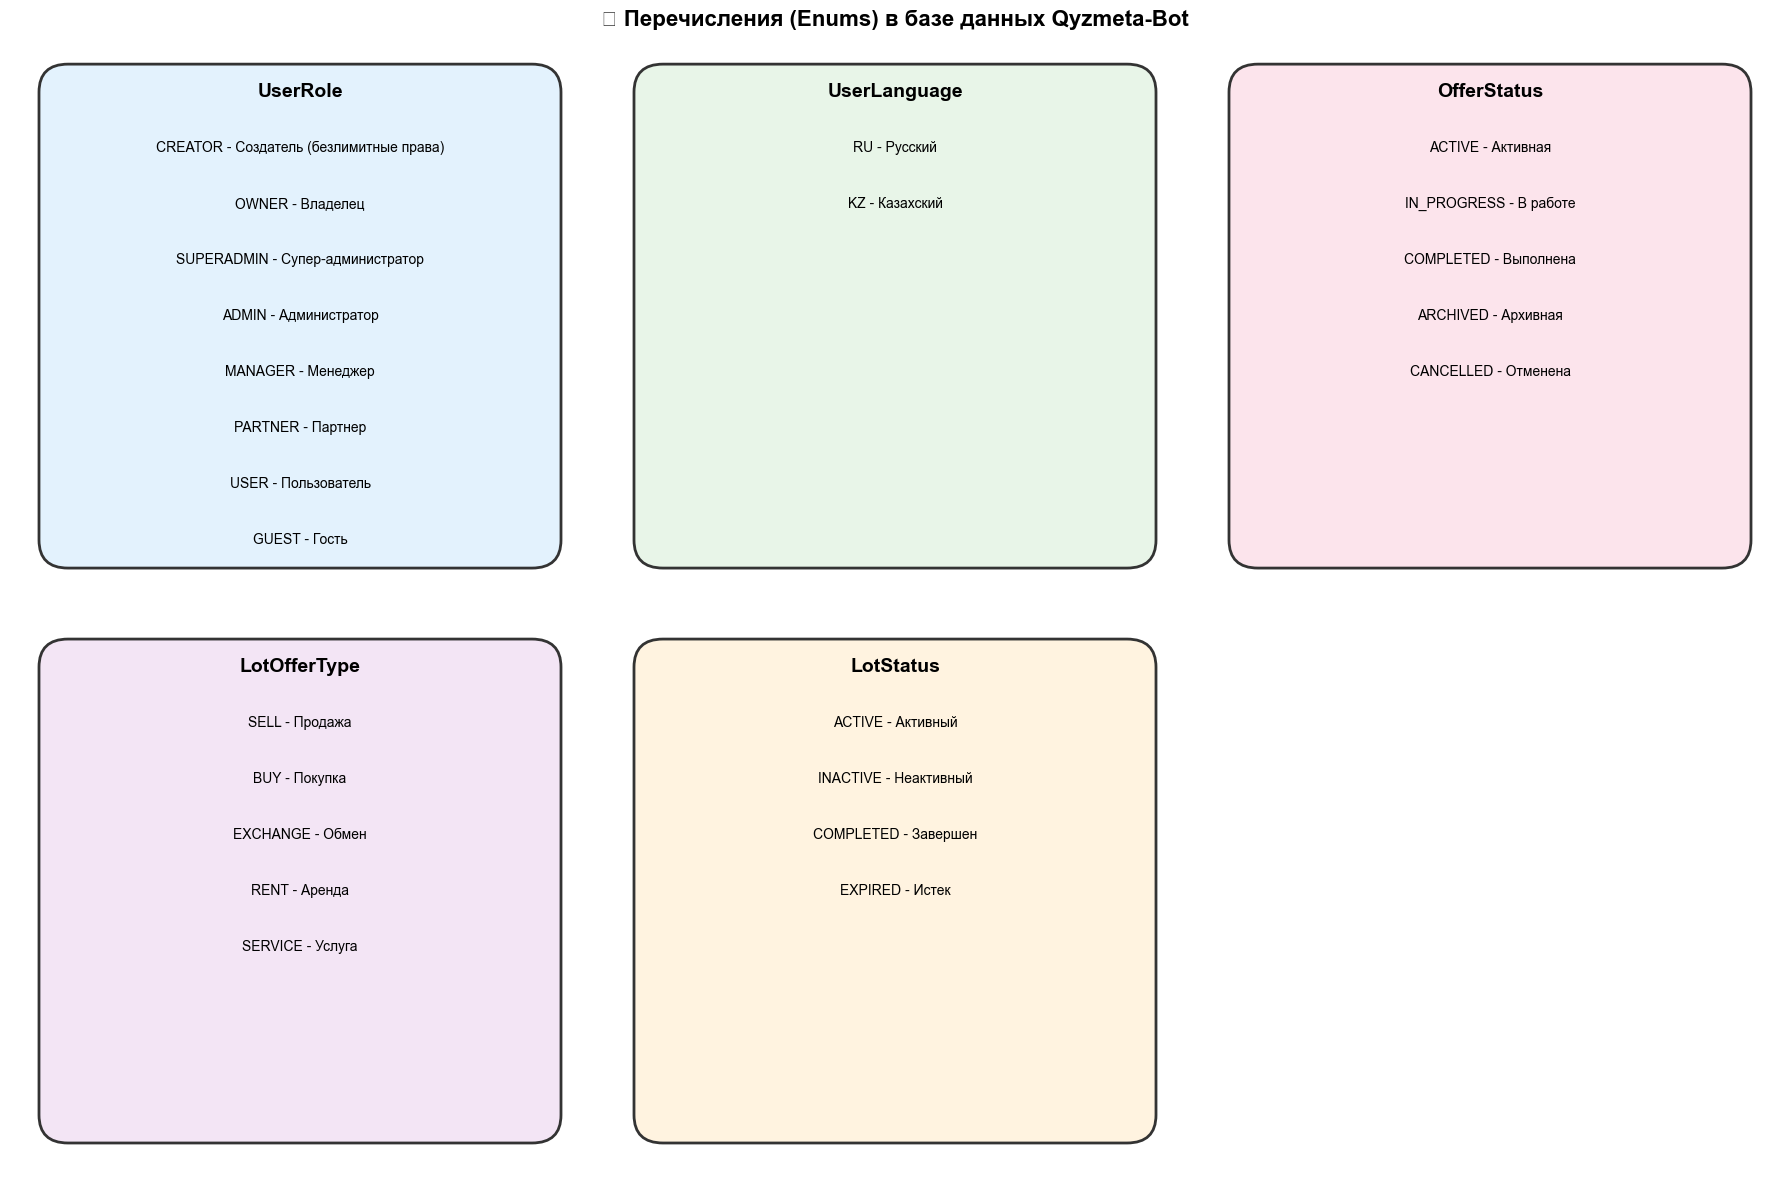

In [7]:
# 🎭 Визуализация перечислений (Enums)

enums_data = {
    'UserRole': {
        'values': [
            'CREATOR - Создатель (безлимитные права)',
            'OWNER - Владелец',
            'SUPERADMIN - Супер-администратор', 
            'ADMIN - Администратор',
            'MANAGER - Менеджер',
            'PARTNER - Партнер',
            'USER - Пользователь',
            'GUEST - Гость'
        ],
        'color': '#E3F2FD'
    },
    'UserLanguage': {
        'values': [
            'RU - Русский',
            'KZ - Казахский'
        ],
        'color': '#E8F5E8'
    },
    'OfferStatus': {
        'values': [
            'ACTIVE - Активная',
            'IN_PROGRESS - В работе',
            'COMPLETED - Выполнена',
            'ARCHIVED - Архивная',
            'CANCELLED - Отменена'
        ],
        'color': '#FCE4EC'
    },
    'LotOfferType': {
        'values': [
            'SELL - Продажа',
            'BUY - Покупка',
            'EXCHANGE - Обмен',
            'RENT - Аренда',
            'SERVICE - Услуга'
        ],
        'color': '#F3E5F5'
    },
    'LotStatus': {
        'values': [
            'ACTIVE - Активный',
            'INACTIVE - Неактивный',
            'COMPLETED - Завершен',
            'EXPIRED - Истек'
        ],
        'color': '#FFF3E0'
    }
}

def create_enums_diagram():
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, (enum_name, enum_data) in enumerate(enums_data.items()):
        if i < len(axes):
            ax = axes[i]
            
            # Создаем прямоугольник для enum
            rect = FancyBboxPatch(
                (0.1, 0.1), 0.8, 0.8,
                boxstyle="round,pad=0.05",
                facecolor=enum_data['color'],
                edgecolor='#333',
                linewidth=2
            )
            ax.add_patch(rect)
            
            # Заголовок
            ax.text(0.5, 0.9, enum_name, ha='center', va='center', 
                   fontsize=14, fontweight='bold', transform=ax.transAxes)
            
            # Значения
            for j, value in enumerate(enum_data['values']):
                y_pos = 0.8 - (j * 0.1)
                ax.text(0.5, y_pos, value, ha='center', va='center', 
                       fontsize=10, transform=ax.transAxes)
            
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.axis('off')
    
    # Убираем лишние подграфики
    for i in range(len(enums_data), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('🎭 Перечисления (Enums) в базе данных Qyzmeta-Bot', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

create_enums_diagram()

C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\775780108.py:89: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\775780108.py:89: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\775780108.py:89: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Local\Temp\ipykernel_14612\775780108.py:89: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Alexandr\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Alexandr\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) A

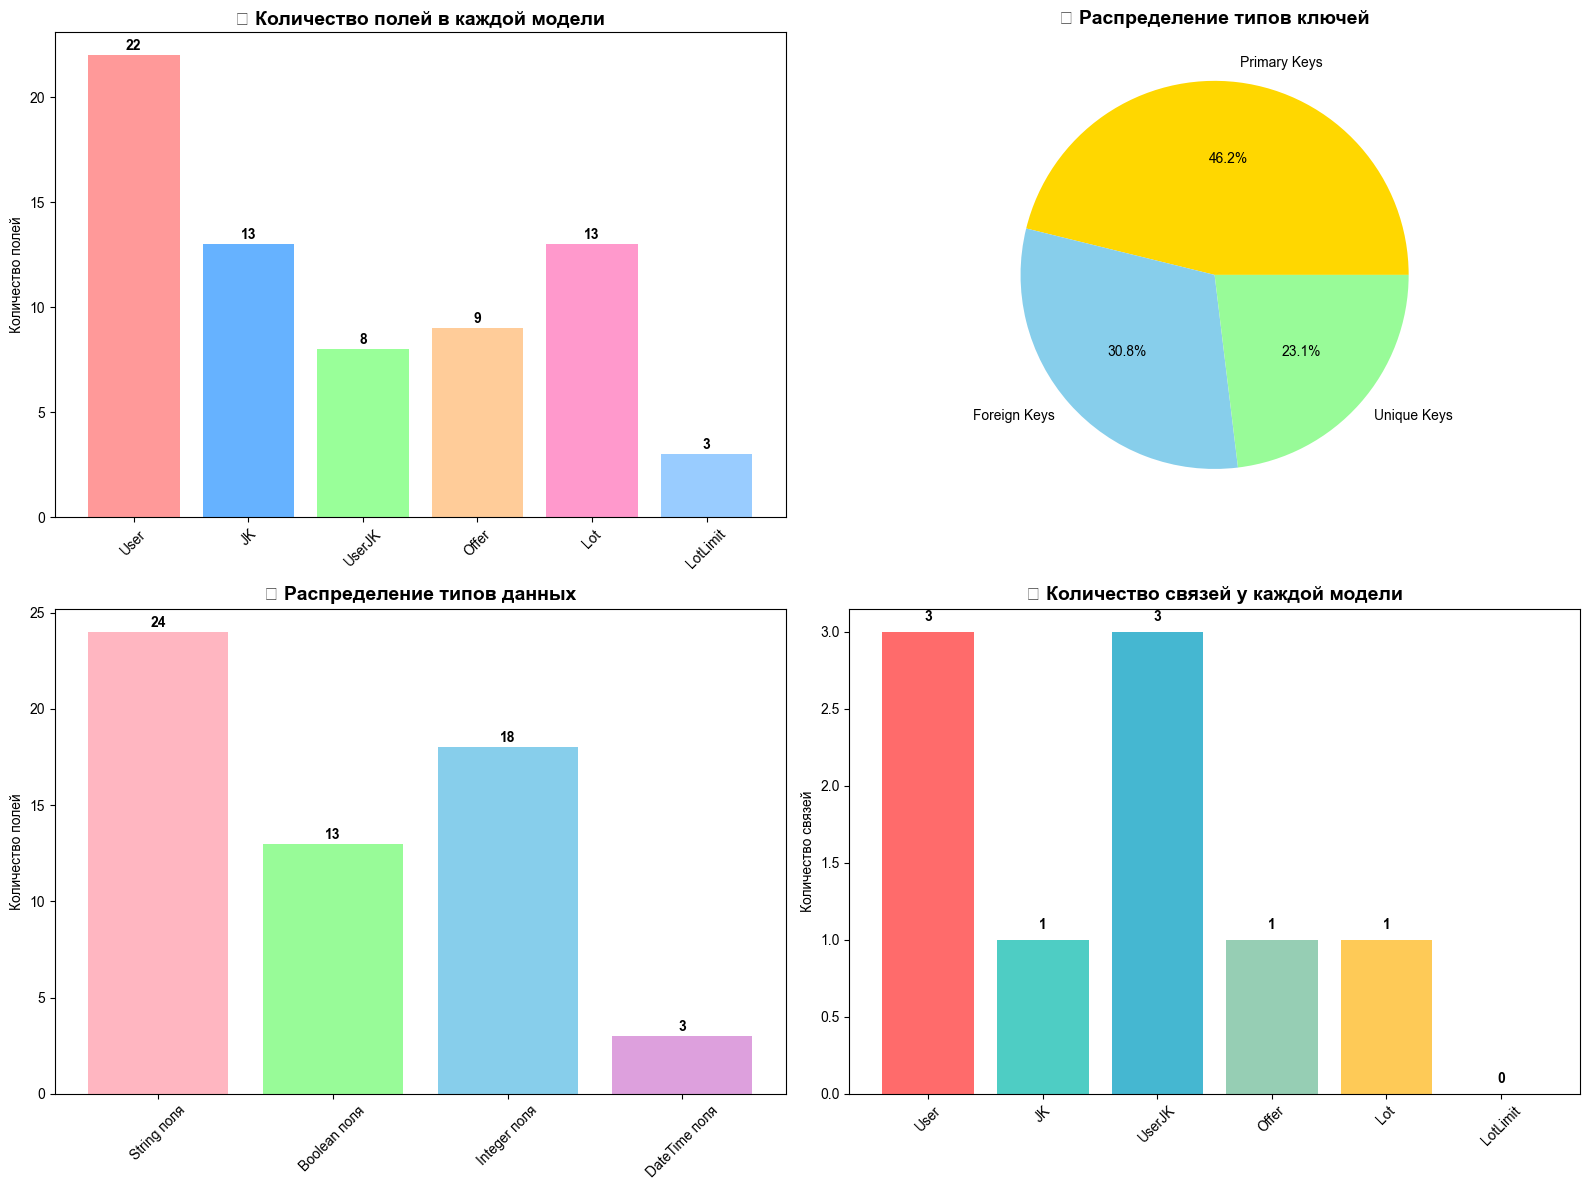

📋 Детальная статистика моделей:
  Модель  Всего полей  Primary Keys  Foreign Keys  Unique Keys  String поля  Boolean поля  Integer поля  DateTime поля
    User           22             1             1            1            6             9             3              2
      JK           13             1             0            1            8             0             5              0
  UserJK            8             1             1            0            1             4             3              0
   Offer            9             1             1            0            4             0             3              0
     Lot           13             1             1            0            5             0             2              1
LotLimit            3             1             0            1            0             0             2              0


In [8]:
# 📈 Статистика и анализ моделей

def create_models_statistics():
    # Подсчет статистики
    stats_data = []
    
    for model_name, model_data in models_structure.items():
        fields = model_data['fields']
        
        # Анализ типов полей
        pk_count = len([f for f in fields if '(PK)' in f])
        fk_count = len([f for f in fields if '(FK' in f])
        uk_count = len([f for f in fields if '(UK)' in f])
        string_count = len([f for f in fields if 'STRING' in f.upper()])
        boolean_count = len([f for f in fields if 'BOOLEAN' in f.upper()])
        integer_count = len([f for f in fields if 'INTEGER' in f.upper()])
        datetime_count = len([f for f in fields if 'DATETIME' in f.upper()])
        
        stats_data.append({
            'Модель': model_name,
            'Всего полей': len(fields),
            'Primary Keys': pk_count,
            'Foreign Keys': fk_count,
            'Unique Keys': uk_count,
            'String поля': string_count,
            'Boolean поля': boolean_count,
            'Integer поля': integer_count,
            'DateTime поля': datetime_count
        })
    
    # Создаем DataFrame
    df = pd.DataFrame(stats_data)
    
    # Создаем графики
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # График 1: Количество полей по моделям
    models = df['Модель']
    field_counts = df['Всего полей']
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF']
    
    bars1 = ax1.bar(models, field_counts, color=colors)
    ax1.set_title('📊 Количество полей в каждой модели', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Количество полей')
    ax1.tick_params(axis='x', rotation=45)
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars1, field_counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(value), ha='center', va='bottom', fontweight='bold')
    
    # График 2: Распределение ключей
    key_types = ['Primary Keys', 'Foreign Keys', 'Unique Keys']
    key_totals = [df[key_type].sum() for key_type in key_types]
    
    wedges, texts, autotexts = ax2.pie(key_totals, labels=key_types, autopct='%1.1f%%',
                                       colors=['#FFD700', '#87CEEB', '#98FB98'])
    ax2.set_title('🔑 Распределение типов ключей', fontsize=14, fontweight='bold')
    
    # График 3: Типы данных
    data_types = ['String поля', 'Boolean поля', 'Integer поля', 'DateTime поля']
    type_totals = [df[data_type].sum() for data_type in data_types]
    
    bars3 = ax3.bar(data_types, type_totals, color=['#FFB6C1', '#98FB98', '#87CEEB', '#DDA0DD'])
    ax3.set_title('📝 Распределение типов данных', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Количество полей')
    ax3.tick_params(axis='x', rotation=45)
    
    for bar, value in zip(bars3, type_totals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(value), ha='center', va='bottom', fontweight='bold')
    
    # График 4: Сложность моделей (количество связей)
    model_connections = {}
    for model in models:
        connections = len([rel for rel in relationships if rel['from'] == model or rel['to'] == model])
        model_connections[model] = connections
    
    bars4 = ax4.bar(model_connections.keys(), model_connections.values(), 
                    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3'])
    ax4.set_title('🔗 Количество связей у каждой модели', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Количество связей')
    ax4.tick_params(axis='x', rotation=45)
    
    for bar, value in zip(bars4, model_connections.values()):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(value), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Выводим таблицу статистики
    print("📋 Детальная статистика моделей:")
    print(df.to_string(index=False))
    
    return df

# Создаем статистику
stats_df = create_models_statistics()

## 🎯 Архитектурный анализ и рекомендации

### ✅ Сильные стороны текущей архитектуры:

1. **🔗 Четкая ролевая модель** - UserJK обеспечивает гибкую привязку пользователей к ЖК с разными ролями
2. **🆔 UUID для API** - готовность к интеграциям и WEB3.0 технологиям
3. **🌐 Универсальная модель User** - подходит для всей экосистемы LotBox Platform
4. **📦 Модель Lot** - центральная концепция платформы для любых сущностей
5. **⚖️ Система лимитов** - предотвращение злоупотреблений через LotLimit

### 🚧 Области для развития (из roadmap):

#### 1. **Привязки каналов и групп к ЖК**
```sql
-- Предлагаемая структура:
JKChannel (
    id, jk_id, channel_id, channel_type, 
    is_active, created_at
)
```

#### 2. **Управляющие компании (УК)**
```sql
-- Расширение модели:
Company (
    id, name, type, contact_info, 
    telegram_group_id, is_verified
)

JKCompany (
    id, jk_id, company_id, role_type,
    contract_start, contract_end
)
```

#### 3. **Автоматические уведомления**
```sql
-- Система уведомлений:
Notification (
    id, offer_id, recipient_type, 
    recipient_id, message, sent_at
)
```

### 🔮 Перспективы развития:

1. **🤖 Интеграция с AI** - для автоматической категоризации заявок
2. **📊 Аналитика** - dashboard для УК и администраторов  
3. **💰 Платежи** - интеграция с казахстанскими платежными системами
4. **📱 Mobile API** - для мобильных приложений жителей
5. **🌍 Мультитенантность** - поддержка разных городов/регионов

### 🛠️ Рекомендации по доработке:

- **Индексы БД**: добавить составные индексы для частых запросов
- **Кэширование**: Redis для кэширования частых запросов по ЖК
- **Аудит**: таблица для логирования изменений критичных данных
- **Архивация**: автоматическое архивирование старых заявок